# Object detection with CORDS

This notebook introduces the CORDS representation for object detection using scenes composed of MNIST digits. We encode the annotated bounding boxes as density and feature fields, reconstruct the boxes from those fields, and examine how the reconstruction changes with the number and spacing of the digits. An optional training section then fits a compact image-to-field network and compares its predictions with the encoded targets.

Install the notebook dependencies from the repository root with `python -m pip install -r requirements.txt`. The examples use bundled MNIST glyphs with recorded source indices and run offline once the dependencies are available. Launch `python -m jupyter lab notebooks/` from the repository root and select the corresponding Python kernel.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "cords").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import math
import torch
import matplotlib.pyplot as plt
from IPython.display import display

torch.set_num_threads(2)
%matplotlib inline
RUN_TRAINING = False  # Enable the optional training section below.
from cords import CORDSTransform
from cords.detection import make_scene, scene_to_fields, decode_boxes
from cords.visualization import plot_scene_roundtrip, detection_metrics

scene = make_scene(seed=7, num_digits=3, image_size=128)
sigma_pixels = 2.56
fields = scene_to_fields(scene, sigma=sigma_pixels)
transform = CORDSTransform(sigma=sigma_pixels, seed=0)
decoded = transform.decode(fields)

## 1. Encoding bounding boxes as fields

Each digit is represented by its center $\mathbf r_i=(x_i,y_i)$ and attributes $\mathbf x_i=[\mathrm{onehot}(c_i),w_i/W,h_i/H]$, where $c_i$ is the class, $w_i$ and $h_i$ are the box dimensions, and $W$ and $H$ are the image dimensions. These annotations define the field targets used for reconstruction and, later, for training the detector.

We place a Gaussian at each center and normalize it over the finite pixel grid:

$$A_{pi}=\frac{\exp[-\|\mathbf r_p-\mathbf r_i\|^2/(2\sigma^2)]}{\sum_{p'}\exp[-\|\mathbf r_{p'}-\mathbf r_i\|^2/(2\sigma^2)]},\qquad \rho_p=\sum_i A_{pi},\qquad H_{p:}=\sum_i A_{pi}\mathbf x_i.$$

Each column of $A$ has unit mass, including for objects near image boundaries, so the total density mass satisfies $\sum_p\rho_p=N$. The resulting representation has 13 channels: one density channel, ten class-mass channels, and two size-mass channels. The feature channels contain Gaussian-weighted sums of the object attributes, which the decoder separates to recover individual classes and dimensions.

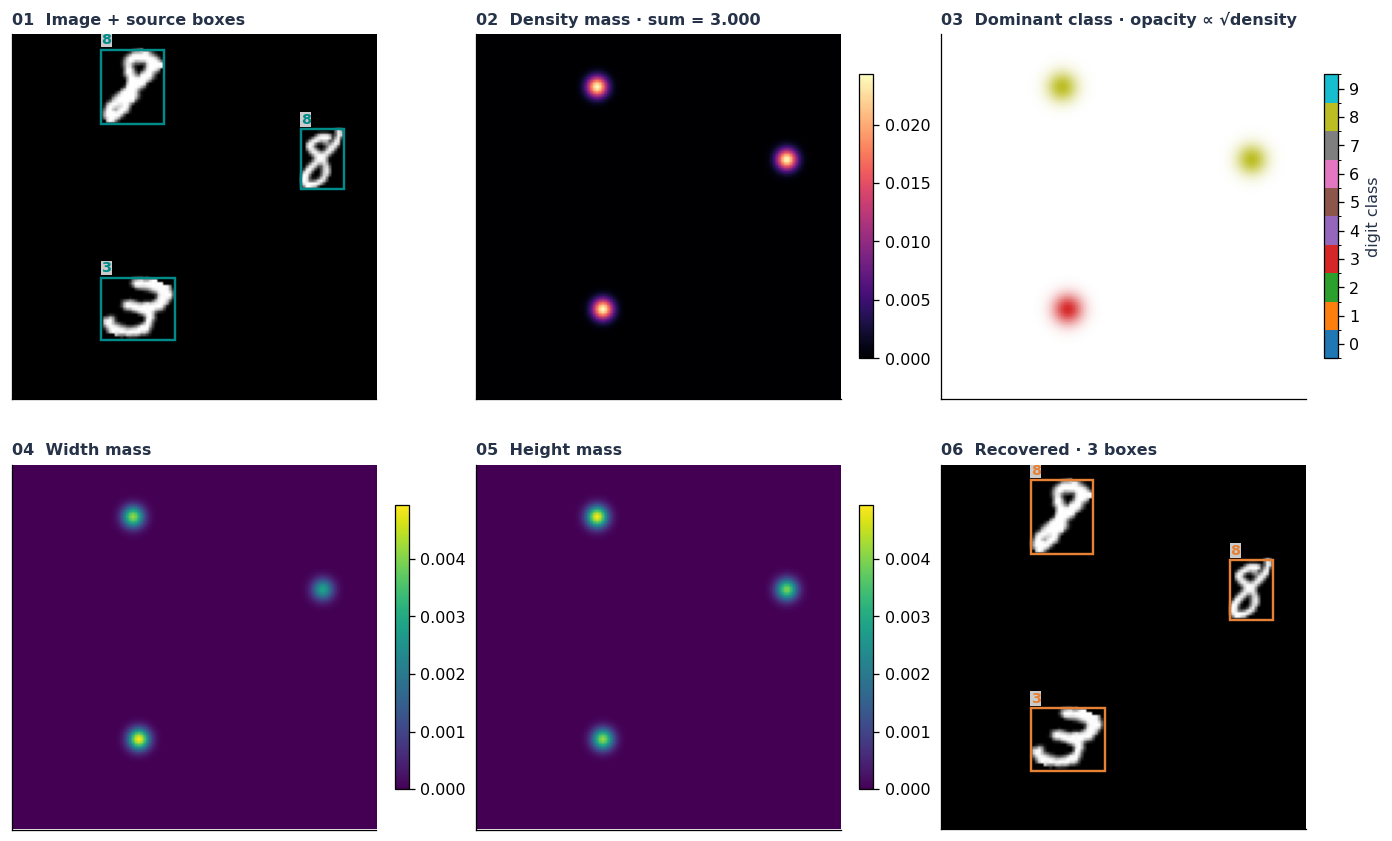

Source digit indices: [137, 7, 41]
Density mass: 3.00000083853345
Class masses: [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0]


In [2]:
fig = plot_scene_roundtrip(scene, fields, decoded)
plt.show()
print("Source digit indices:", scene.source_indices.tolist())
print("Density mass:", fields.count_estimate())
print("Class masses:", fields.features[:, :10].sum(0).round().tolist())

## 2. Reconstructing bounding boxes

The decoder first rounds the total density mass to estimate the number of objects. It initializes that many centers from density peaks and refines their positions by fitting unit-mass Gaussian kernels to the density. With the fitted kernel matrix $A$, it recovers the class and size attributes jointly through a regularized least-squares solve:

$$\widehat X=(A^\top A+\lambda I)^{-1}A^\top H.$$

The largest recovered class component determines each digit's label. The remaining components give its normalized width and height, which are combined with the recovered center to form a bounding box. The decoder follows the same procedure for analytically encoded fields and model predictions; the fitting residual measures how closely either input can be represented by the fitted Gaussian kernels.

In [3]:
metrics = detection_metrics(scene, decoded)
print(metrics)
print({key: decoded.diagnostics[key] for key in
       ("density_relative_error", "feature_relative_error", "gram_condition_number")})
assert metrics["count_correct"]
assert metrics["class_accuracy"] == 1.0 and metrics["matched_iou"] > 0.95
print("Decoded boxes [x0, y0, x1, y1]:\n", decode_boxes(decoded, scene.image_shape).round(decimals=2))

{'true_count': 3, 'decoded_count': 3, 'count_correct': True, 'matched_iou': 0.9999997615814209, 'class_accuracy': 1.0, 'center_rms_pixels': 0.0}
{'density_relative_error': 3.604555924685095e-07, 'feature_relative_error': 1.0611994287527243e-07, 'gram_condition_number': 1.000000000000359}
Decoded boxes [x0, y0, x1, y1]:
 tensor([[ 31.,   5.,  53.,  31.],
        [ 31.,  85.,  57., 107.],
        [101.,  33., 116.,  54.]])


## 3. Reconstruction with more objects and overlapping kernels

The first scene below contains 16 digits and illustrates how the representation accommodates different set sizes. Because these fields are constructed directly from annotations, this experiment evaluates reconstruction rather than a trained detector's ability to generalize to new object counts. The second scene places digits close together and uses a wider Gaussian bandwidth to show the effect of overlapping kernels. As their centers approach one another, separating their contributions can become numerically ambiguous.

Object counts are computed from the fields on their original pixel grid. Any resizing used to display a density map must preserve its total mass.

16-digit scene: {'true_count': 16, 'decoded_count': 16, 'count_correct': True, 'matched_iou': 0.9999994039535522, 'class_accuracy': 1.0, 'center_rms_pixels': 0.0}


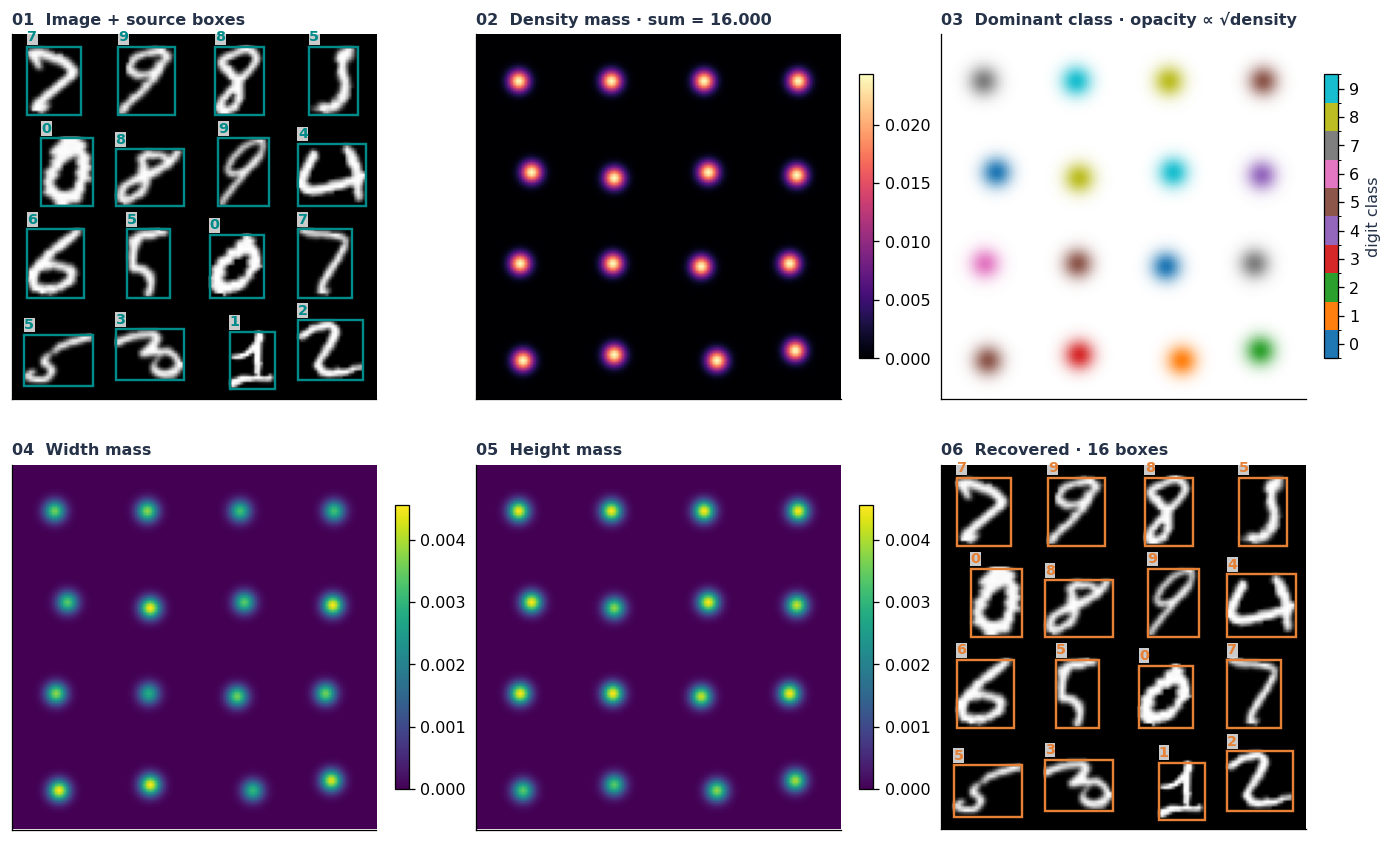

In [4]:
crowded = make_scene(seed=11, num_digits=16, image_size=128)
crowded_fields = scene_to_fields(crowded, sigma=sigma_pixels)
crowded_decoded = transform.decode(crowded_fields)
print("16-digit scene:", detection_metrics(crowded, crowded_decoded))
fig = plot_scene_roundtrip(crowded, crowded_fields, crowded_decoded)
plt.show()

Overlapping scene: {'true_count': 16, 'decoded_count': 16, 'count_correct': True, 'matched_iou': 0.8576087355613708, 'class_accuracy': 0.875, 'center_rms_pixels': 0.6041384935379028}
Density residual: 0.00034627803414579453


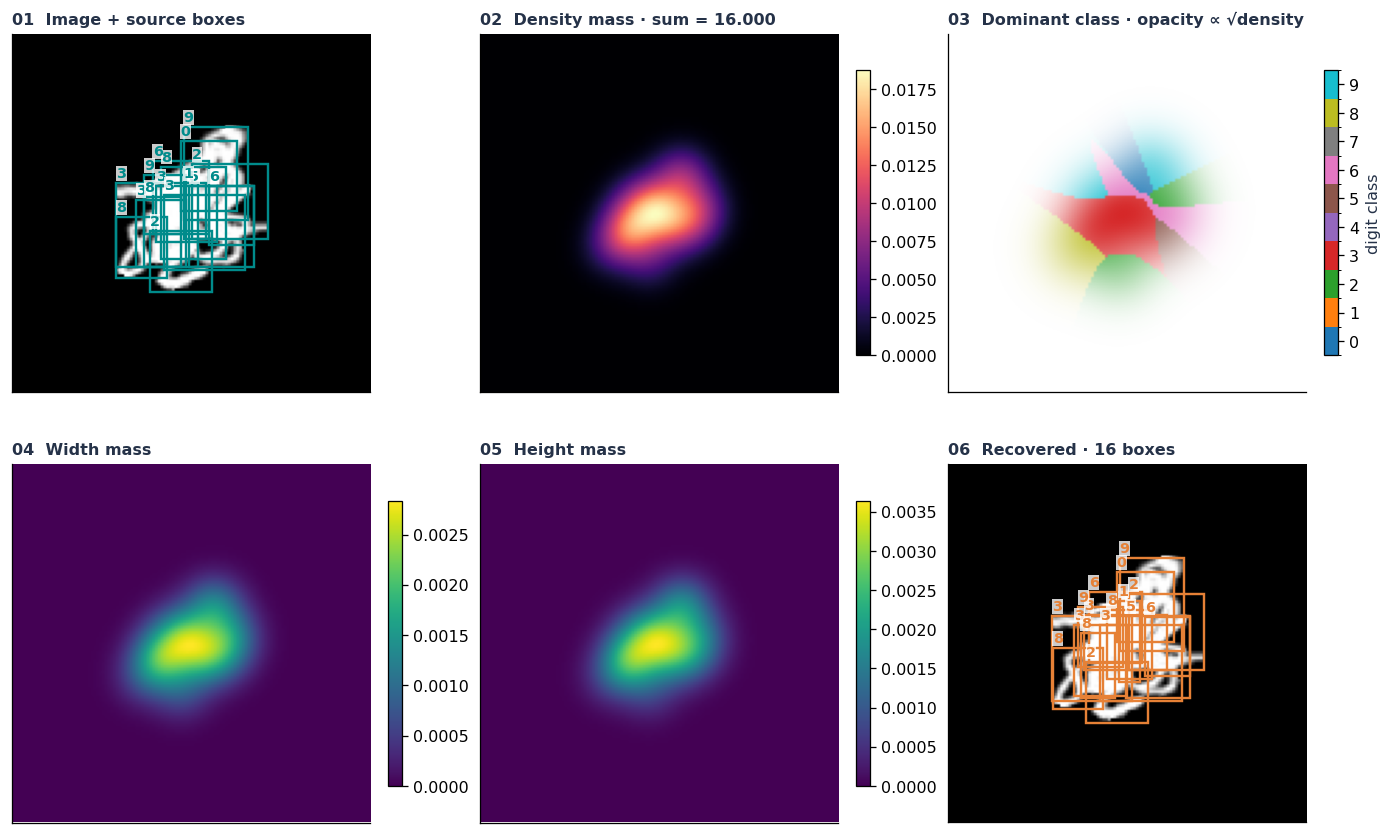

In [5]:
overlapping = make_scene(seed=7, num_digits=16, image_size=128, overlap=True)
overlap_fields = scene_to_fields(overlapping, sigma=7.0)
overlap_decoded = CORDSTransform(sigma=7.0, seed=0).decode(overlap_fields)
print("Overlapping scene:", detection_metrics(overlapping, overlap_decoded))
print("Density residual:", overlap_decoded.diagnostics["density_relative_error"])
fig = plot_scene_roundtrip(overlapping, overlap_fields, overlap_decoded)
plt.show()

In the overlapping example, a small density residual can accompany errors in recovered classes and sizes. Strong overlap makes the feature Gram matrix $A^\top A$ ill-conditioned, so small changes in the fitted centers or fields can produce large changes in the recovered attributes. Comparing matched boxes and labels with the source annotations helps reveal errors that the field residual alone can miss.

## 4. Interactive reconstruction

The controls below vary the number of digits, Gaussian bandwidth, and spatial arrangement. Press **Recompute roundtrip** after changing the settings to compare the source annotations, encoded fields, and reconstructed boxes.

In [6]:
import ipywidgets as widgets

digits = widgets.IntSlider(value=3, min=1, max=16, description="Digits", continuous_update=False)
bandwidth = widgets.FloatSlider(value=2.56, min=1.0, max=7.0, step=0.25, description="σ / pixels", continuous_update=False)
overlap = widgets.Checkbox(value=False, description="Cluster digits")
recompute = widgets.Button(description="Recompute roundtrip", button_style="info")
exploration = widgets.Output()

def update_scene(_):
    with exploration:
        exploration.clear_output(wait=True)
        sample = make_scene(seed=7, num_digits=digits.value, overlap=overlap.value)
        sampled = scene_to_fields(sample, sigma=bandwidth.value)
        recovered = CORDSTransform(sigma=bandwidth.value).decode(sampled)
        print(detection_metrics(sample, recovered))
        print("Density residual:", recovered.diagnostics["density_relative_error"])
        plot_scene_roundtrip(sample, sampled, recovered)
        plt.show()

recompute.on_click(update_scene)
display(widgets.VBox([digits, bandwidth, overlap, recompute, exploration]))

## 5. Predicting fields from images

The CORDS detector uses a compact ConvNeXt/FPN network to predict 13 field channels from an image. Its outputs parameterize a positive density, class probabilities, and normalized box dimensions as

$$\rho=\mathrm{softplus}(a),\quad\pi=\mathrm{softmax}(b),\quad\mu=\mathrm{sigmoid}(c),\quad f_\theta(I)=[\rho,\rho\pi,\rho\mu].$$

Training compares these predictions with the fields encoded from the annotated boxes and includes a count penalty:

$$\mathcal L=\mathcal L_{\mathrm{fields}}+\lambda_N\left(\frac{\sum_p\widehat\rho_p-N}{\max(N,1)}\right)^2.$$

The targets use the same finite-grid normalization as the reconstruction examples. At inference, the network maps image pixels to fields, and the decoder estimates the object count, centers, classes, and box dimensions from those predicted fields.

## 6. Optional detector training

Set `RUN_TRAINING = True` near the beginning of the notebook to fit the detector on a small fixed batch and inspect the loss curve, predicted fields, and reconstructed boxes. This overfitting example demonstrates the training procedure; evaluating generalization or reproducing the paper's detection results requires a separate experiment. To train on varying scenes from a supplied MNIST glyph archive, run `python -m cords.train mnist --full-data --data /path/to/glyphs.npz --output runs/mnist`. Run this command from the repository root. The scene generator derives its randomness from the seed, epoch, and sample index so that data-loader workers produce distinct, reproducible samples.

In [7]:
if RUN_TRAINING:
    from cords.train import train_overfit, load_checkpoint
    from cords.visualization import plot_training_history, plot_learning_example
    device = "cuda" if torch.cuda.is_available() else "cpu"
    learned = train_overfit("mnist", steps=120, output=REPO_ROOT / "runs/mnist-notebook", device=device)
    plot_training_history(learned["history"])
    plt.show()
    plot_learning_example(learned)
    plt.show()
    reloaded_model, checkpoint = load_checkpoint(learned["checkpoint"], device=device)
    print("Saved and reloaded:", learned["checkpoint"])
else:
    print("Set RUN_TRAINING = True to run the detector training example.")

Set RUN_TRAINING = True to run the detector training example.


For the trained model, the field residual and estimated count help explain the reconstructed detections. Large predicted density mass can imply more objects than the decoder is configured to fit; in that case, decoding reports the configured limit so the prediction can be inspected.

Further details are available in the [CORDS paper](https://arxiv.org/abs/2601.21583), [implementation provenance](../docs/provenance.md), and [data source documentation](../cords/data/README.md).